## A9

**Data Analytics II**

1. Implement logistic regression using Python/R to perform classification on Social_Network_Ads.csv dataset.

2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset


**Link of Dataset**

Social Network Ads: https://www.kaggle.com/datasets/akram24/social-network-ads

**1) Import Required Libraries**

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# For label encoding, splitting dataset and building model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

**2) Load the Dataset**

In [73]:
# Load the Social Network Ads dataset
df = pd.read_csv("Social_Network_Ads.csv")

In [74]:
# Display first 5 rows
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


**3) Understand Dataset Structure**

In [75]:
# Dimmensions of dataset
df.shape

(400, 5)

In [76]:
# Datatypes of each column
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

<b>Description</b>

This dataset contains information about users of a social network and whether they purchased a product after seeing an advertisement.

- **User ID** (`int64`)  
  A unique identifier assigned to each user. This column does not affect purchasing behavior and is typically removed during model training.

- **Gender** (`object`)  
  The gender of the user (Male/Female). This is a categorical variable.

- **Age** (`int64`)  
  The age of the user in years. This is a numerical feature and often an important factor in predicting purchasing behavior.

- **EstimatedSalary** (`int64`)  
  The estimated annual salary of the user. This numerical feature may influence purchasing decisions.

- **Purchased** (`int64`)  
  Target variable indicating whether the user purchased the product:
  - `0` → Did not purchase  
  - `1` → Purchased  

In [77]:
# Display info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [78]:
# Display statistical summary
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


**4) Handle missing values**

In [79]:
# Check missing values
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

<b>5) Handle Categorical Variable (Gender Encoding)</b>

0 -> Female

1 -> Male

In [80]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [81]:
# Gender is now encoded into int
df.dtypes

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

In [82]:
# Display updated statistical summary
df.describe()

,User ID,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000,400.000000
mean,1.569154e+07,0.490000,37.655000,69742.500000,0.357500
std,7.165832e+04,0.500526,10.482877,34096.960282,0.479864
min,1.556669e+07,0.000000,18.000000,15000.000000,0.000000
25%,1.562676e+07,0.000000,29.750000,43000.000000,0.000000
50%,1.569434e+07,0.000000,37.000000,70000.000000,0.000000
75%,1.575036e+07,1.000000,46.000000,88000.000000,1.000000
max,1.581524e+07,1.000000,60.000000,150000.000000,1.000000


<b>6) Boxplot for Outliers</b>

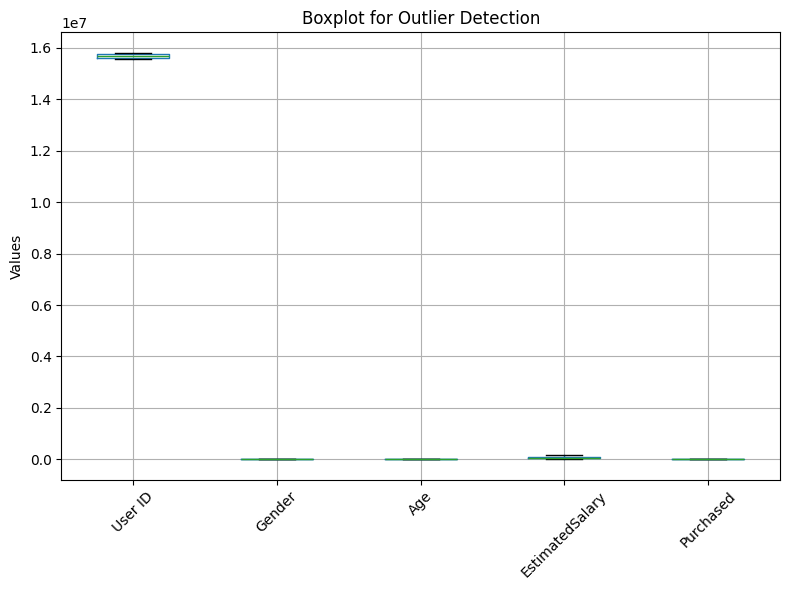

In [83]:
plt.figure(figsize=(8, 6))
df.boxplot()
plt.title('Boxplot for Outlier Detection')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>Inference: No Outliers present</b>

<b>7) Define Features (X) and Target (y)</b>

X → Independent variables:
- Gender
- Age
- EstimatedSalary

y → Dependent variable:
- Purchased

In [84]:
X = df[['Gender', 'Age', 'EstimatedSalary']]  # Features
y = df['Purchased']                           # Target

<b>9) Split Dataset (Train-Test Split)(80:20)</b>

In [85]:
# Split dataset into training and testing (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

<b>10) Feature Scaling - Standard Scaling</b>

In [86]:
# Apply Standard Scaling

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

<b>11) Train Logistic Regression Model</b>

In [87]:
# Create Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

LogisticRegression()

<b>12) Make Predictions</b>

In [88]:
# Predict test data
y_pred = model.predict(X_test)

In [89]:
# Print predictions
print(y_pred)

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1]


<b>13) Evaluate Model</b>

<b> - Compute Confusion Matrix</b>

In [90]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56  2]
 [ 5 17]]


<b>- Extract TP, FP, FN, TP values</b>

In [91]:
# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Positive:", TP)
print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)

True Positive: 17
True Negative: 56
False Positive: 2
False Negative: 5


<b>- Performance Metrics</b>

Accuracy = (TP + TN) / Total

Error Rate = (FP + FN) / Total

Precision = TP / (TP + FP)

Recall = TP / (TP + FN)

In [92]:
# Total observations
total = TP + TN + FP + FN

# Accuracy
accuracy = (TP + TN) / total

# Error Rate
error_rate = (FP + FN) / total
#OR
#error_rate = 1 - accuracy

# Precision
precision = TP / (TP + FP)

# Recall
recall = TP / (TP + FN)

print("Accuracy:", np.round(accuracy, 2))
print("Error Rate:", np.round(error_rate, 2))
print("Precision:", np.round(precision, 2))
print("Recall:", np.round(recall, 2))

Accuracy: 0.91
Error Rate: 0.09
Precision: 0.89
Recall: 0.77
